# 08 - Evaluate Per-Crop Disease Classifiers

Stage 8: Evaluate trained disease classifiers on their held-out test sets.

Automatically skips any crop whose model file doesn't exist yet -- so this
runs fine right now with only Cotton and Tomato trained, and you can
re-run it as you finish the other three crops without editing anything.

Reports per crop:
  - classification_report (precision/recall/F1 per disease class)
  - macro-F1 (watch this over raw accuracy, given class imbalance)
  - confusion matrix, saved as confusion_matrix_<crop>.png

Install deps:
    pip install scikit-learn matplotlib seaborn --break-system-packages

## Imports & Configuration

In [1]:
import json
from pathlib import Path

import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

DATA_ROOT = Path("disease_dataset")
MODELS_DIR = Path("models")
IMG_SIZE = 224
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CROPS = ["Cotton", "Groundnut", "Pepper Bell", "Potato", "Tomato"]

eval_tf = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

z:\Crop Identification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## `load_model_and_labels`

In [2]:
def load_model_and_labels(crop_slug):
    model_path = MODELS_DIR / f"disease_{crop_slug}.pth"
    labels_path = MODELS_DIR / f"disease_{crop_slug}_labels.json"
    if not model_path.exists() or not labels_path.exists():
        return None, None
    with open(labels_path) as f:
        classes = json.load(f)
    model = timm.create_model("efficientnet_b2", pretrained=False, num_classes=len(classes))
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    return model, classes

## `evaluate_test_set`

In [3]:
def evaluate_test_set(model, classes, test_dir):
    y_true, y_pred = [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = test_dir / class_name
        if not class_dir.exists():
            continue
        for img_path in class_dir.iterdir():
            image = cv2.imread(str(img_path))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            tensor = eval_tf(image=image)["image"].unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                output = model(tensor)
                pred_idx = output.argmax(dim=1).item()
            y_true.append(class_idx)
            y_pred.append(pred_idx)
    return np.array(y_true), np.array(y_pred)

## `plot_confusion`

In [4]:
def plot_confusion(y_true, y_pred, classes, crop_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(6, len(classes)), max(5, len(classes) * 0.8)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{crop_name} Disease Classifier - Confusion Matrix (Test Set)")
    plt.tight_layout()
    out_path = f"confusion_matrix_{crop_name.replace(' ', '_')}.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved: {out_path}")

## `evaluate_crop`

In [5]:
def evaluate_crop(crop_name):
    crop_slug = crop_name.replace(" ", "_")
    model, classes = load_model_and_labels(crop_slug)
    if model is None:
        print(f"[{crop_name}] No trained model found yet -- skipping.")
        return None

    test_dir = DATA_ROOT / crop_slug / "test"
    y_true, y_pred = evaluate_test_set(model, classes, test_dir)

    print(f"\n{'=' * 20} {crop_name} {'=' * 20}")
    print(classification_report(y_true, y_pred, target_names=classes, digits=3, zero_division=0))
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"Macro-F1: {macro_f1:.4f}")
    plot_confusion(y_true, y_pred, classes, crop_name)
    return macro_f1

## `evaluate_all_trained_crops`

In [6]:
def evaluate_all_trained_crops():
    results = {}
    for crop in CROPS:
        macro_f1 = evaluate_crop(crop)
        if macro_f1 is not None:
            results[crop] = macro_f1

    print(f"\n{'=' * 20} Summary {'=' * 20}")
    for crop, f1 in results.items():
        print(f"{crop:15s} macro-F1: {f1:.4f}")
    if len(results) < len(CROPS):
        remaining = [c for c in CROPS if c not in results]
        print(f"\nNot yet trained: {remaining}")

## Run


==================== Cotton ====================
              precision    recall  f1-score   support

         ALS      0.960     0.923     0.941        26
          BB      0.895     0.791     0.840        43
          CV      1.000     0.923     0.960        13
          FW      0.966     0.966     0.966        88
           H      0.947     0.964     0.956        56
          PM      0.833     0.833     0.833         6
          TS      0.600     0.500     0.545         6
          VW      0.826     0.974     0.894        39

    accuracy                          0.921       277
   macro avg      0.878     0.859     0.867       277
weighted avg      0.922     0.921     0.920       277

Macro-F1: 0.8669


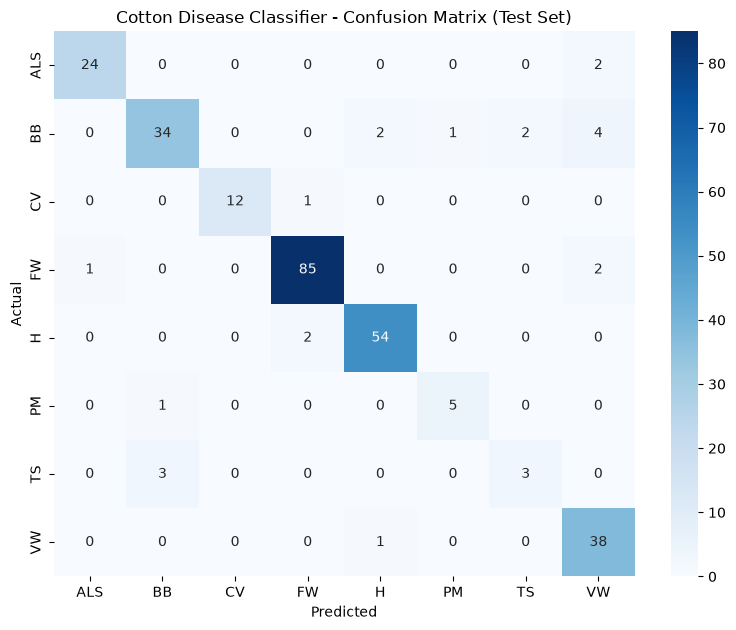

Saved: confusion_matrix_Cotton.png

==================== Groundnut ====================
              precision    recall  f1-score   support

         ALS      0.981     0.914     0.946        58
           H      0.873     0.965     0.917       228
          LS      0.959     0.881     0.918       294
          ND      0.885     0.939     0.911        49
           R      0.943     0.962     0.952        52
         Ros      1.000     1.000     1.000        14

    accuracy                          0.924       695
   macro avg      0.940     0.943     0.941       695
weighted avg      0.927     0.924     0.924       695

Macro-F1: 0.9408


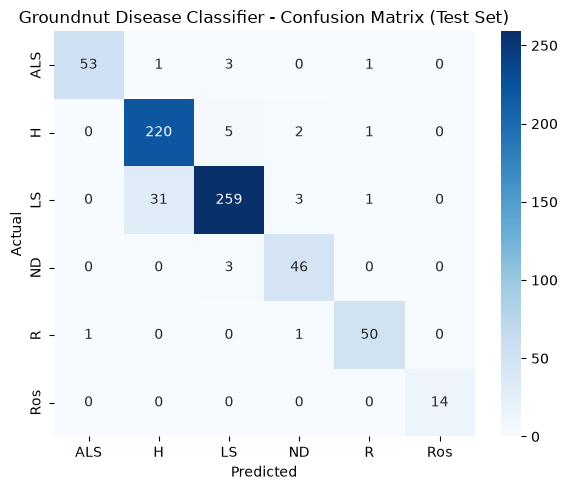

Saved: confusion_matrix_Groundnut.png

==================== Pepper Bell ====================
              precision    recall  f1-score   support

          BS      0.998     0.993     0.995       536
         CLS      0.995     0.990     0.993       210
           E      0.600     0.600     0.600         5
           H      0.991     0.987     0.989       227
          LC      0.926     0.980     0.952        51
          ND      0.950     0.983     0.966        58
          PM      0.964     0.964     0.964        28

    accuracy                          0.987      1115
   macro avg      0.918     0.928     0.923      1115
weighted avg      0.988     0.987     0.988      1115

Macro-F1: 0.9228


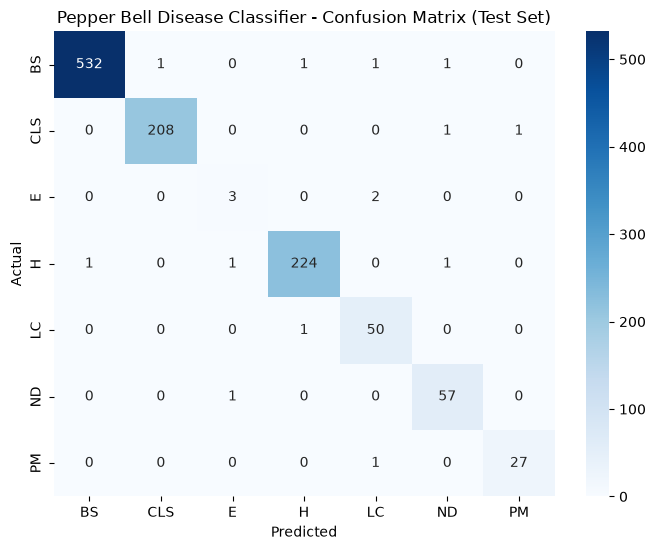

Saved: confusion_matrix_Pepper_Bell.png

==================== Potato ====================
              precision    recall  f1-score   support

           B      0.929     0.940     0.935        84
          EB      0.993     1.000     0.996       266
           F      0.831     0.891     0.860       110
           H      0.973     0.969     0.971       224
          LB      0.975     0.955     0.965       290
           N      0.667     0.400     0.500        10
           P      0.827     0.744     0.784        90
           V      0.816     0.910     0.861        78

    accuracy                          0.937      1152
   macro avg      0.876     0.851     0.859      1152
weighted avg      0.937     0.937     0.936      1152

Macro-F1: 0.8589


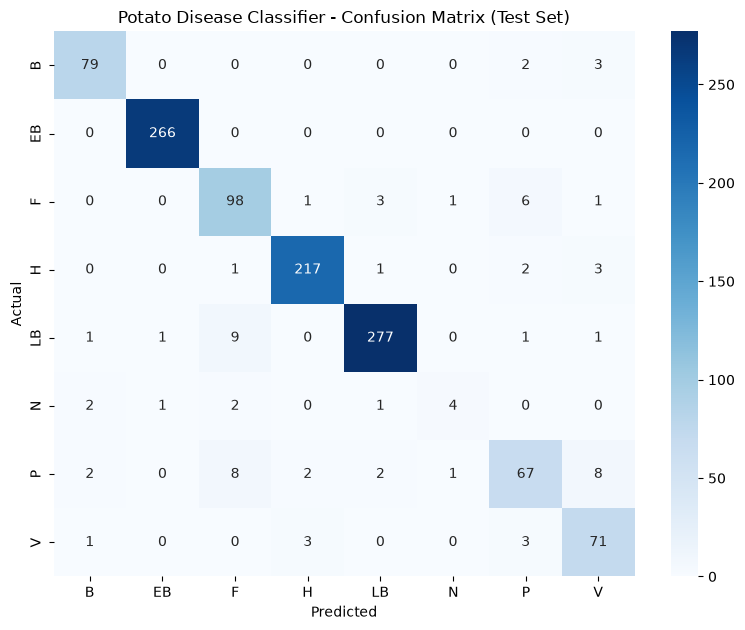

Saved: confusion_matrix_Potato.png

==================== Tomato ====================
              precision    recall  f1-score   support

          BS      0.983     0.929     0.955       182
          EB      0.905     0.955     0.929       220
           H      0.944     0.976     0.959       206
          LB      0.968     0.916     0.941       166
          ML      0.843     0.933     0.886        75
          MV      0.556     0.357     0.435        14
           S      0.696     0.711     0.703        45
         YCV      0.824     0.667     0.737        21

    accuracy                          0.918       929
   macro avg      0.840     0.805     0.818       929
weighted avg      0.918     0.918     0.917       929

Macro-F1: 0.8182


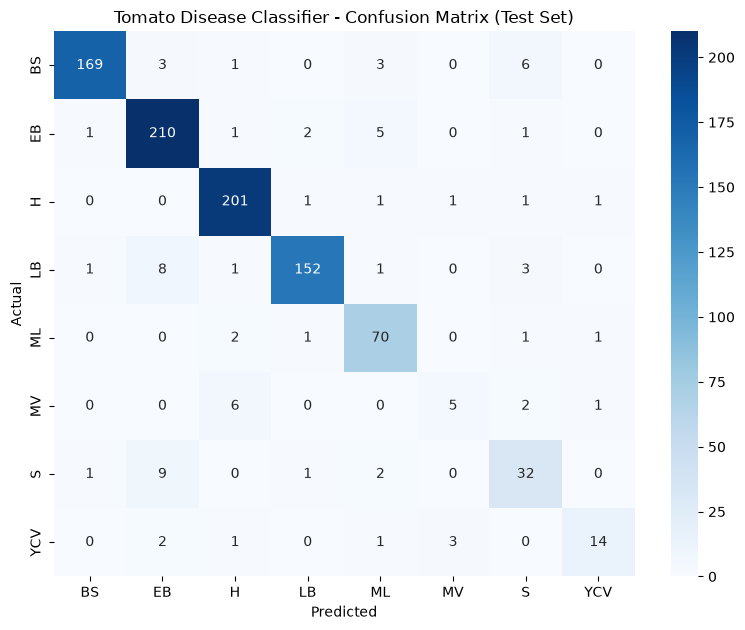

Saved: confusion_matrix_Tomato.png

==================== Summary ====================
Cotton          macro-F1: 0.8669
Groundnut       macro-F1: 0.9408
Pepper Bell     macro-F1: 0.9228
Potato          macro-F1: 0.8589
Tomato          macro-F1: 0.8182


In [7]:
evaluate_all_trained_crops()